In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
pd.set_option('display.max_columns', 1000)


In [2]:
from pyspark.sql.functions import sum as _sum
from pyspark.sql.functions import when, col, countDistinct, datediff, collect_set, ceil, lit, broadcast
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import IntegerType, FloatType, StringType, DateType

In [3]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Split") \
    .config("spark.driver.memory", "10g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
spark.conf.set("spark.sql.shuffle.partitions", "400")
csv_file_path = "data/OASIS_v2.csv"
df = spark.read.csv(csv_file_path, header=True, inferSchema=True)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/27 14:47:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

In [4]:
df.show(5)

+---------------+---------------+-------------------------+---------------------+--------------------+--------------------------+--------+---------------+--------------------+----------------------+------------+------------------------+------------------+--------------------------+-----------------------+-------------+----------------+------------------+------+--------------------------------+-----+-------------------------+------------------+----------------------------------+----------------------+-----+------------------------+-------------------------+-----------------------+-----------------------------+----------------------------------------------------------------+---------------------------------+--------------------------------+--------------------------------+---------------------------------+----------------------------------+---------------------------------------------------------+------------------------------------+--------------------------+----------------------------

In [5]:
df.columns

['Beneficiary_ID',
 'Assessment_ID',
 'Assessment_Effective_Date',
 'Calculated_HIPPS_Code',
 'Facility_Internal_ID',
 'HHA_Assessment_Internal_ID',
 'State_ID',
 'Submission_Date',
 'Submitted_HIPPS_Code',
 'Agency_Medicare_Number',
 'Branch_State',
 'Branch_Identifier_Number',
 'Start_of_Care_Date',
 'Resumption_of_Care_Date_NA',
 'Resumption_of_Care_Date',
 'Patient_State',
 'Patient_ZIP_Code',
 'Patient_Birth_Date',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'Unknown_Race_Ethnicity',
 'White',
 'Medicare_Fee_For_Service',
 'Medicare_HMO_Managed_Care',
 'Date_of_Last_Home_Visit',
 'Discharge_Transfer_Death_Date',
 'Medicare_HHA_pymnt_episode_asmt_case_mix_grp_early_later_episode',
 'Discharged_Past_14_Days_From_IPPS',
 'Discharged_Past_14_Days_From_IRF',
 'Discharged_Past_14_Days_From_LTC',
 'Discharged_Past_14_Days_From_LTCH',
 'Discharged_Past_14_Days_From_Other',
 'Discharg

In [6]:
dates = [
    col for col in df.columns 
    if col.startswith("Date") 
    or col.startswith("date") 
    or col.endswith("Date") 
    or col.endswith("date")
]

for d in dates:
    df = df.withColumn(d, F.to_date(F.col(d), "ddMMMyyyy"))

In [7]:
df.printSchema()

root
 |-- Beneficiary_ID: string (nullable = true)
 |-- Assessment_ID: string (nullable = true)
 |-- Assessment_Effective_Date: date (nullable = true)
 |-- Calculated_HIPPS_Code: string (nullable = true)
 |-- Facility_Internal_ID: integer (nullable = true)
 |-- HHA_Assessment_Internal_ID: string (nullable = true)
 |-- State_ID: string (nullable = true)
 |-- Submission_Date: date (nullable = true)
 |-- Submitted_HIPPS_Code: string (nullable = true)
 |-- Agency_Medicare_Number: string (nullable = true)
 |-- Branch_State: string (nullable = true)
 |-- Branch_Identifier_Number: string (nullable = true)
 |-- Start_of_Care_Date: date (nullable = true)
 |-- Resumption_of_Care_Date_NA: integer (nullable = true)
 |-- Resumption_of_Care_Date: date (nullable = true)
 |-- Patient_State: string (nullable = true)
 |-- Patient_ZIP_Code: integer (nullable = true)
 |-- Patient_Birth_Date: date (nullable = true)
 |-- Gender: string (nullable = true)
 |-- American_Indian_or_Alaska_Native: integer (nullab

In [8]:
window_spec = Window.partitionBy("Beneficiary_ID", 'Assessment_Effective_Date').orderBy("Assessment_Effective_Date")
df = df.withColumn("NumVisits", F.count("Assessment_ID").over(window_spec))
df = df.withColumn("PrevVisitDate", F.lag("Assessment_Effective_Date").over(window_spec))
df = df.withColumn("DaysBetweenVisits", F.datediff("Assessment_Effective_Date", "PrevVisitDate"))

In [9]:
df = df.withColumn("Start_of_Care_Date", F.to_date("Start_of_Care_Date", "ddMMMyyyy"))
# Get the last resumption of care date per BENE_ID
last_admission = df.groupBy("Beneficiary_ID").agg(F.max("Assessment_Effective_Date").alias("Assessment_Effective_Date_last"))
# Merge with original dataframe to get the last admission date for each BENE_ID
df = df.join(last_admission, on="Beneficiary_ID", how="left")
# Calculate days cared for
df = df.withColumn("Days_Cared_For", F.datediff("Assessment_Effective_Date_last", "Start_of_Care_Date"))

In [10]:
df = df.withColumn(
    "READMISSION",
    when(datediff(col("Resumption_of_Care_Date"), col("Assessment_Effective_Date")) < 30, 1).otherwise(0)
)


In [11]:
df_counts = df.groupBy("READMISSION").count()
df_counts.show()

[Stage 3:======================================================>(111 + 1) / 112]

+-----------+--------+
|READMISSION|   count|
+-----------+--------+
|          0|14353049|
|          1| 1401281|
+-----------+--------+



In [12]:
df = df.withColumn("Patient_Birth_Date", F.to_date("Patient_Birth_Date", "ddMMMyyyy"))
df = df.withColumn("Age", datediff(col("Assessment_Effective_Date"), col("Patient_Birth_Date")) / 365)

In [13]:
df.columns


['Beneficiary_ID',
 'Assessment_ID',
 'Assessment_Effective_Date',
 'Calculated_HIPPS_Code',
 'Facility_Internal_ID',
 'HHA_Assessment_Internal_ID',
 'State_ID',
 'Submission_Date',
 'Submitted_HIPPS_Code',
 'Agency_Medicare_Number',
 'Branch_State',
 'Branch_Identifier_Number',
 'Start_of_Care_Date',
 'Resumption_of_Care_Date_NA',
 'Resumption_of_Care_Date',
 'Patient_State',
 'Patient_ZIP_Code',
 'Patient_Birth_Date',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'Unknown_Race_Ethnicity',
 'White',
 'Medicare_Fee_For_Service',
 'Medicare_HMO_Managed_Care',
 'Date_of_Last_Home_Visit',
 'Discharge_Transfer_Death_Date',
 'Medicare_HHA_pymnt_episode_asmt_case_mix_grp_early_later_episode',
 'Discharged_Past_14_Days_From_IPPS',
 'Discharged_Past_14_Days_From_IRF',
 'Discharged_Past_14_Days_From_LTC',
 'Discharged_Past_14_Days_From_LTCH',
 'Discharged_Past_14_Days_From_Other',
 'Discharg

In [14]:
# Create a column 'is_deceased': 1 if death date exists, 0 otherwise
df = df.withColumn(
    "is_deceased",
    F.when(F.col("Discharge_Transfer_Death_Date").isNotNull(), 1).otherwise(0)
)


In [15]:
df = df.drop('Start_of_Care_Date', 'Resumption_of_Care_Date',"Resumption_of_Care_Date_NA", 'Assessment_Effective_Date_last', 'Start_of_Care_Date', 'HHA_Assessment_Internal_ID', 'Submission_Date',  'Branch_Identifier_Number', 'Patient_Birth_Date', 'Date_of_Last_Home_Visit', 'Discharge_Transfer_Death_Date')
df

DataFrame[Beneficiary_ID: string, Assessment_ID: string, Assessment_Effective_Date: date, Calculated_HIPPS_Code: string, Facility_Internal_ID: int, State_ID: string, Submitted_HIPPS_Code: string, Agency_Medicare_Number: string, Branch_State: string, Patient_State: string, Patient_ZIP_Code: int, Gender: string, American_Indian_or_Alaska_Native: int, Asian: int, Black_or_African_American: int, Hispanic_or_Latino: int, Native_Hawiian_or_Pacific_Islander: int, Unknown_Race_Ethnicity: string, White: int, Medicare_Fee_For_Service: int, Medicare_HMO_Managed_Care: int, Medicare_HHA_pymnt_episode_asmt_case_mix_grp_early_later_episode: string, Discharged_Past_14_Days_From_IPPS: int, Discharged_Past_14_Days_From_IRF: int, Discharged_Past_14_Days_From_LTC: int, Discharged_Past_14_Days_From_LTCH: int, Discharged_Past_14_Days_From_Other: int, Discharged_Past_14_Days_From_Psychiatric_Hospital_Or_Unit: int, Discharged_Past_14_Days_From_SNF_TCU: int, Discharged_Past_14_Days_NA: int, Most_Recent_Inpat_D

In [16]:
distribution = df.groupBy("is_deceased") \
                 .agg(F.countDistinct("Beneficiary_ID").alias("num_patients"))

# Add percentage
total = df.select("Beneficiary_ID").distinct().count()
distribution = distribution.withColumn("percent", (F.col("num_patients")/total)*100)

distribution.show()

[Stage 14:========>                                             (16 + 84) / 100]

+-----------+------------+-----------------+
|is_deceased|num_patients|          percent|
+-----------+------------+-----------------+
|          0|     4589776|94.60155343743996|
|          1|     4237229|87.33507815417796|
+-----------+------------+-----------------+



In [17]:
from pyspark.sql import functions as F
from pyspark.sql.types import StringType


# ICD diagnosis columns
icd_cols = [
    "Inpatient_Diagnosis_1_ICD_10_C_M","Inpatient_Diagnosis_2_ICD_10_C_M","Inpatient_Diagnosis_3_ICD_10_C_M",
    "Inpatient_Diagnosis_4_ICD_10_C_M","Inpatient_Diagnosis_5_ICD_10_C_M","Inpatient_Diagnosis_6_ICD_10_C_M",
    "Inpatient_Diagnosis_ICD_10_C_M_Not_Applicable",
    "Primary_Diagnosis_ICD_10_C_M_Code","Primary_Diagnosis_Severity_Rating_ICD_10_C_M_Code",
    "Primary_Optional_Diagnosis_ICD_10_C_M_Code","Primary_Optional_Diagnosis_Multiple_Codes_ICD_10_C_M"
]
icd_df = df.select([F.col(c).cast("string").alias(c) for c in icd_cols])

# ------------------------------
# 2. Convert columns → rows
# ------------------------------
icd_values = (
    icd_df
    .select(F.explode(F.array(*icd_cols)).alias("icd_code"))
    .filter(
        (F.col("icd_code").isNotNull()) &
        (F.col("icd_code") != "") &
        (~F.col("icd_code").isin("Not Applicable", "nan", "None"))
    )
)

# ------------------------------
# 3. Count unique ICD values
# ------------------------------
unique_icd_count = icd_values.select("icd_code").distinct().count()

print(f"Unique ICD values across all ICD columns: {unique_icd_count}")
def get_code(icd_values):
    if icd_values is None:
        return []
    prefixes = ("E08", "E09", "E10", "E11", "E13", "I50", "I10", "I11", "I12", "I13", "I15")
    types = set()
    for val in icd_values:
        if val is not None:
            for prefix in prefixes:
                if val.startswith(prefix):
                    types.add(prefix)
    return list(types)

get_code_udf = F.udf(get_code, F.ArrayType(StringType()))
df_with_array = df.withColumn("icd_array", F.array(*[F.col(c).cast("string") for c in icd_cols]))
df_with_types = df_with_array.withColumn("code", get_code_udf(F.col("icd_array")))
df_exploded = df_with_types.withColumn("code", F.explode(F.col("code")))
counts = df_exploded.groupBy("code").agg(F.countDistinct("Beneficiary_ID").alias("num_patients"))
counts.show()

Unique ICD values across all ICD columns: 37367


[Stage 24:=====================================================>(110 + 2) / 112]

+----+------------+
|code|num_patients|
+----+------------+
| I50|      440009|
| E10|       15609|
| I12|      117843|
| E08|        3615|
| E09|        1755|
| I13|      185527|
| E13|        8790|
| I11|      257480|
| I10|      436945|
| E11|      580759|
| I15|        2238|
+----+------------+



In [18]:

# Exact ICD codes or prefixes for each condition
ICD_CODE_MAP = {
    "Diabetes": ["E08", "E09", "E10", "E11", "E13"],           # add all relevant diabetes codes
    "HeartFailure": ["I50"],                      # add relevant heart failure codes
    "Hypertension": ["I10", "I11", "I12", "I13", "I15"],
}

# Function to classify a patient based on ICD codes
def classify_conditions_exact(*codes):
    results = {cond: 0 for cond in ICD_CODE_MAP}

    for code in codes:
        if code is None:
            continue
        code = str(code).strip()
        if code == "":
            continue

        for cond, code_list in ICD_CODE_MAP.items():
            # Partial match: check if code starts with any prefix in the list
            if any(code.startswith(prefix) for prefix in code_list):
                results[cond] = 1

    return (results["Diabetes"], results["HeartFailure"],
            results["Hypertension"])

# Create UDF
classify_udf = F.udf(
    classify_conditions_exact,
    "struct<diabetes:int,heartfailure:int,hypertension:int>"
)

# Apply UDF
df = df.withColumn("conditions", classify_udf(*[F.col(c) for c in icd_cols]))

# Expand struct into separate columns
df = df \
    .withColumn("is_diabetes", F.col("conditions.diabetes")) \
    .withColumn("is_heart_failure", F.col("conditions.heartfailure")) \
    .withColumn("is_hypertension", F.col("conditions.hypertension")) \
    .drop("conditions")


In [19]:
patient_df = (
    df.groupBy("Beneficiary_ID")
      .agg(
          F.max("is_deceased").alias("ever_deceased"),
          F.max("READMISSION").alias("ever_readmitted"),
          F.max("is_diabetes").alias("has_diabetes"),
          F.max("is_heart_failure").alias("has_heart_failure"),
          F.max("is_hypertension").alias("has_hypertension")
      )
)


In [20]:
distribution = (
    patient_df.groupBy(
        "has_diabetes",
    )
    .agg(
        F.count("*").alias("num_patients"),
        F.mean("ever_deceased").alias("mortality_rate"),
        F.mean("ever_readmitted").alias("readmission_rate")  # <-- use the patient-level column
    )
)
total_patients = patient_df.count()  # make sure you define this
distribution = distribution.withColumn(
    "percent_of_population",
    (F.col("num_patients") / total_patients) * 100
)
distribution.show()

[Stage 36:=====================================================>(111 + 1) / 112]

+------------+------------+------------------+------------------+---------------------+
|has_diabetes|num_patients|    mortality_rate|  readmission_rate|percent_of_population|
+------------+------------+------------------+------------------+---------------------+
|           0|     4252390|0.8749505572160596|0.1354845157664278|    87.64756707556869|
|           1|      599302|0.8619994593710684|0.2757274295764072|   12.352432924431312|
+------------+------------+------------------+------------------+---------------------+



In [21]:
patient_df.columns

['Beneficiary_ID',
 'ever_deceased',
 'ever_readmitted',
 'has_diabetes',
 'has_heart_failure',
 'has_hypertension']

In [22]:
df_patient_level = df.join(
    patient_df,
    on="Beneficiary_ID",
    how="left"
)
df_patient_level.show()

[Stage 50:=================================================>      (50 + 7) / 57]

+---------------+---------------+-------------------------+---------------------+--------------------+--------+--------------------+----------------------+------------+-------------+----------------+------+--------------------------------+-----+-------------------------+------------------+----------------------------------+----------------------+-----+------------------------+-------------------------+----------------------------------------------------------------+---------------------------------+--------------------------------+--------------------------------+---------------------------------+----------------------------------+---------------------------------------------------------+------------------------------------+--------------------------+-----------------------------------+------------------------------------+-----------------------------------+-----------------------------+----------------------------+--------------------------------------+----------------------+---------

In [23]:
print(f"Shape: Rows={df_patient_level.count()}, Columns={len(df_patient_level.columns)}")

Shape: Rows=15754330, Columns=301


# State EDA

In [24]:
state_counts = (
    df_patient_level
    .groupBy("STATE_ID")
    .agg(F.countDistinct("Beneficiary_ID").alias("num_patients"))
    .orderBy(F.desc("num_patients"))
)

# Take top 10 states
top_states = [row.STATE_ID for row in state_counts.limit(3).collect()]
print("Top 3 states:", top_states)
top_states_df = df_patient_level.filter(F.col("STATE_ID").isin(top_states))

Top 3 states: ['CA', 'FL', 'TX']


In [25]:
distinct_states = state_counts.select("STATE_ID").distinct()
state_list = [row.STATE_ID for row in state_counts.select("STATE_ID").distinct().collect()]
print(state_list)


[Stage 66:=====================================================>(111 + 1) / 112]

['CA', 'FL', 'TX', 'NY', 'PA', 'OH', 'MI', 'IL', 'MA', 'NC', 'GA', 'VA', 'NJ', 'TN', 'AL', 'MO', 'LA', 'SC', 'IN', 'CT', 'KY', 'MD', 'OK', 'MS', 'MN', 'WA', 'AZ', 'CO', 'WI', 'AR', 'OR', 'NV', 'KS', 'WV', 'IA', 'UT', 'NM', 'ME', 'PR', 'NH', 'NE', 'RI', 'ID', 'DE', 'VT', 'HI', 'MT', 'SD', 'DC', 'ND', 'WY', 'AK', 'VI']


In [26]:
distribution_top_states = (
    top_states_df.groupBy(
        "STATE_ID",
        "has_diabetes",
        "has_heart_failure",
        "has_hypertension"
    )
    .agg(
        F.count("*").alias("num_patients"),
        F.mean("ever_deceased").alias("mortality_rate"),
        F.mean("ever_readmitted").alias("readmission_rate")
    )
)
# Total patients per state (needed for percent)
state_totals = (
    top_states_df.groupBy("STATE_ID")
    .agg(F.count("*").alias("total_patients"))
)

# Join totals back to compute percentages
distribution_top_states = distribution_top_states.join(
    state_totals, on="STATE_ID"
).withColumn(
    "percent_of_state_population",
    (F.col("num_patients") / F.col("total_patients")) * 100
)
distribution_top_states.orderBy("STATE_ID", "has_diabetes", "has_heart_failure", "has_hypertension").show(30)


[Stage 81:=============>(110 + 2) / 112][Stage 84:>               (0 + 79) / 79]

+--------+------------+-----------------+----------------+------------+------------------+-------------------+--------------+---------------------------+
|STATE_ID|has_diabetes|has_heart_failure|has_hypertension|num_patients|    mortality_rate|   readmission_rate|total_patients|percent_of_state_population|
+--------+------------+-----------------+----------------+------------+------------------+-------------------+--------------+---------------------------+
|      CA|           0|                0|               0|      769635|0.9212444860225951| 0.1792408089548942|       1339344|         57.463579185033865|
|      CA|           0|                0|               1|      213392| 0.941370810527105|0.23978405938366948|       1339344|         15.932575947628091|
|      CA|           0|                1|               0|       44448|0.9495815334773218| 0.4090622750179986|       1339344|         3.3186395728057914|
|      CA|           0|                1|               1|       68867|0.969

# Texas focused

In [27]:
filtered_df = df_patient_level.filter(F.col("STATE_ID") == "TX")

In [28]:
distribution_TX = (
    filtered_df.groupBy(
        "has_diabetes",
        "has_heart_failure",
        "has_hypertension"
    )
    .agg(
        F.count("*").alias("num_patients"),
        F.mean("ever_deceased").alias("mortality_rate"),
        F.mean("ever_readmitted").alias("readmission_rate")  # <-- use the patient-level column
    )
)
total_patients = filtered_df.count()  # make sure you define this
distribution_TX = distribution_TX.withColumn(
    "percent_of_population",
    (F.col("num_patients") / total_patients) * 100
)
print(f"Shape: Rows={filtered_df.count()}, Columns={len(filtered_df.columns)}")
distribution_TX.show()

Shape: Rows=1552306, Columns=301


[Stage 98:====================================================> (108 + 4) / 112]

+------------+-----------------+----------------+------------+------------------+------------------+---------------------+
|has_diabetes|has_heart_failure|has_hypertension|num_patients|    mortality_rate|  readmission_rate|percent_of_population|
+------------+-----------------+----------------+------------+------------------+------------------+---------------------+
|           0|                0|               0|      693325|0.8723282731763603|0.2360004326975084|    44.66419636334589|
|           1|                1|               1|       51312|0.9619971936389149|0.7829357655129404|   3.3055338316027894|
|           1|                0|               0|      192977|0.8176881182731621|0.3322934857521881|   12.431633969075685|
|           0|                1|               1|       85879|0.9370276784778584|0.6601963227331478|    5.532349936159495|
|           1|                0|               1|      135685|0.8219921140877768|0.4437999778899657|    8.740866813630818|
|           1|  

# Filter by top feats (BIGDATA-23)

In [30]:
cols = ['Beneficiary_ID', 'Assessment_Effective_Date', 'Submitted_HIPPS_Code', 'Facility_Internal_ID','Age','Gender',
        'American_Indian_or_Alaska_Native','Asian','Black_or_African_American', 'Hispanic_or_Latino', 
        'Native_Hawiian_or_Pacific_Islander', 'Unknown_Race_Ethnicity', 'White',  'ByDiscipline', 'DaysBetweenVisits',
        'Days_Cared_For', 'READMISSION', 'Patient_ZIP_Code', 'Agency_Medicare_Number', 'Primary_Diagnosis_ICD_10_C_M_Code',
        'Other_Diagnosis_Code_1_ICD_10_C_M', 'Other_Diagnosis_Code_2_ICD_10_C_M',
        'Other_Diagnosis_Code_3_ICD_10_C_M', 'Other_Diagnosis_Code_4_ICD_10_C_M',
        'Other_Diagnosis_Code_5_ICD_10_C_M', 'Weight_in_pounds', 'Height_in_inches', 'has_diabetes', 'has_heart_failure','READMISSION',
        'has_hypertension', 'ever_deceased','ever_readmitted']
df_topFeats = filtered_df.select(cols).dropDuplicates(subset=['Beneficiary_ID','ever_readmitted', 'ever_deceased'])

In [31]:
# 1. Cast weight, height, and age to double/int
df_topFeats = df_topFeats.withColumn("Weight_in_pounds", col("Weight_in_pounds").cast("double"))
df_topFeats = df_topFeats.withColumn("Height_in_inches", col("Height_in_inches").cast("double"))
df_topFeats = df_topFeats.withColumn("Age", col("Age").cast("int"))


In [32]:
# 2. Calculate BMI using standard formula
df_topFeats = df_topFeats.withColumn(
    "BMI",
    (col("Weight_in_pounds") / (col("Height_in_inches") ** 2)) * 703
)
# 3. Filter out extreme/unrealistic BMI values
df_topFeats = df_topFeats.filter((col("BMI") > 10) & (col("BMI") < 80))

# 4. Categorize BMI accurately
df_topFeats = df_topFeats.withColumn(
    "BMI_Category",
    when(col("BMI") < 18.5, "Underweight")
    .when((col("BMI") >= 18.5) & (col("BMI") < 25), "Normal weight")
    .when((col("BMI") >= 25) & (col("BMI") < 30), "Overweight")
    .when((col("BMI") >= 30) & (col("BMI") < 35), "Obese-Class1")
    .when((col("BMI") >= 35) & (col("BMI") < 40), "Obese-Class2")
    .otherwise("Obese-Class3")
)

In [33]:
df_topFeats = df_topFeats.drop('Weight_in_pounds','Height_in_inches')


In [34]:
df_topFeats = df_topFeats.drop('Unknown_Race_Ethnicity','DaysBetweenVisits')


In [35]:
df_topFeats = df_topFeats.drop('READMISSION', 'is_deceased', 'is_diabetes', 'is_heart_failure', 'is_hypertension')


In [36]:
df_topFeats.columns

['Beneficiary_ID',
 'Assessment_Effective_Date',
 'Submitted_HIPPS_Code',
 'Facility_Internal_ID',
 'Age',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'White',
 'ByDiscipline',
 'Days_Cared_For',
 'Patient_ZIP_Code',
 'Agency_Medicare_Number',
 'Primary_Diagnosis_ICD_10_C_M_Code',
 'Other_Diagnosis_Code_1_ICD_10_C_M',
 'Other_Diagnosis_Code_2_ICD_10_C_M',
 'Other_Diagnosis_Code_3_ICD_10_C_M',
 'Other_Diagnosis_Code_4_ICD_10_C_M',
 'Other_Diagnosis_Code_5_ICD_10_C_M',
 'has_diabetes',
 'has_heart_failure',
 'has_hypertension',
 'ever_deceased',
 'ever_readmitted',
 'BMI',
 'BMI_Category']

In [37]:
df_pandas = df_topFeats.toPandas()

In [38]:
df_pandas.columns

Index(['Beneficiary_ID', 'Assessment_Effective_Date', 'Submitted_HIPPS_Code',
       'Facility_Internal_ID', 'Age', 'Gender',
       'American_Indian_or_Alaska_Native', 'Asian',
       'Black_or_African_American', 'Hispanic_or_Latino',
       'Native_Hawiian_or_Pacific_Islander', 'White', 'ByDiscipline',
       'Days_Cared_For', 'Patient_ZIP_Code', 'Agency_Medicare_Number',
       'Primary_Diagnosis_ICD_10_C_M_Code',
       'Other_Diagnosis_Code_1_ICD_10_C_M',
       'Other_Diagnosis_Code_2_ICD_10_C_M',
       'Other_Diagnosis_Code_3_ICD_10_C_M',
       'Other_Diagnosis_Code_4_ICD_10_C_M',
       'Other_Diagnosis_Code_5_ICD_10_C_M', 'has_diabetes',
       'has_heart_failure', 'has_hypertension', 'ever_deceased',
       'ever_readmitted', 'BMI', 'BMI_Category'],
      dtype='object')

In [39]:
sdoh_geo = pd.read_csv('data/texas_sdoh_tract_georef_census.csv')
sdoh_geo

,zip,primary_city,area_codes,COUNTY_NAME,POP_COU,HOU_COU,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ANY,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_CIVIL_NONINST_POP_POV,ACS_TOT_CIVIL_POP_POV,ACS_TOT_POP_POV
0,75763,Frankston,"430, 903",Anderson,57922.0,20131.0,18615.0,32.14,39307.0,67.86,48001,7.841667,32.505833,4.401667,38.8575,16.396667,0.484167,44.747500,21.754167,43.486667,34.760000,1.988333,45.035833,67.546667,12.244167,52.398333,13.515000,0.416667,67.963333,2.157500,11.7675,21.545833,6.0100,0.0,61.189167,4.223333,16.269167,72.360000,12.733333,46.878333,0.6250,10.084167,30.835000,37.776667,20.465833,33.424167,23.509167,29.446667,10.115833,16.695833,103.250000,19.629167,32.141667,21.355000,26.874167,27.555000,10.730833,4.674167,6.685833,12.410833,4.845833,2.404167,18.850000,4.595833,21.844167,53.496667,20.064167,18.616667,9.615,22.0325,21.848333,22.510833,0.0,10.224167,9.229167,2.745,3700.166667,2778.083333,3700.166667
1,75779,Neches,"430, 903",Anderson,57922.0,20131.0,18615.0,32.14,39307.0,67.86,48001,7.841667,32.505833,4.401667,38.8575,16.396667,0.484167,44.747500,21.754167,43.486667,34.760000,1.988333,45.035833,67.546667,12.244167,52.398333,13.515000,0.416667,67.963333,2.157500,11.7675,21.545833,6.0100,0.0,61.189167,4.223333,16.269167,72.360000,12.733333,46.878333,0.6250,10.084167,30.835000,37.776667,20.465833,33.424167,23.509167,29.446667,10.115833,16.695833,103.250000,19.629167,32.141667,21.355000,26.874167,27.555000,10.730833,4.674167,6.685833,12.410833,4.845833,2.404167,18.850000,4.595833,21.844167,53.496667,20.064167,18.616667,9.615,22.0325,21.848333,22.510833,0.0,10.224167,9.229167,2.745,3700.166667,2778.083333,3700.166667
2,75801,Palestine,"430, 903",Anderson,57922.0,20131.0,18615.0,32.14,39307.0,67.86,48001,7.841667,32.505833,4.401667,38.8575,16.396667,0.484167,44.747500,21.754167,43.486667,34.760000,1.988333,45.035833,67.546667,12.244167,52.398333,13.515000,0.416667,67.963333,2.157500,11.7675,21.545833,6.0100,0.0,61.189167,4.223333,16.269167,72.360000,12.733333,46.878333,0.6250,10.084167,30.835000,37.776667,20.465833,33.424167,23.509167,29.446667,10.115833,16.695833,103.250000,19.629167,32.141667,21.355000,26.874167,27.555000,10.730833,4.674167,6.685833,12.410833,4.845833,2.404167,18.850000,4.595833,21.844167,53.496667,20.064167,18.616667,9.615,22.0325,21.848333,22.510833,0.0,10.224167,9.229167,2.745,3700.166667,2778.083333,3700.166667
3,75802,Palestine,903,Anderson,57922.0,20131.0,18615.0,32.14,39307.0,67.86,48001,7.841667,32.505833,4.401667,38.8575,16.396667,0.484167,44.747500,21.754167,43.48666

In [40]:
zip_county_combinations = sdoh_geo.groupby(["zip", "COUNTY_NAME"]).size().reset_index(name="Count")
zip_county_combinations

,zip,COUNTY_NAME,Count
0,73301,Travis,1
1,73344,Travis,1
2,73960,Sherman,1
3,75001,Dallas,1
4,75002,Collin,1
...,...,...,...
2643,88587,El Paso,1
2644,88588,El Paso,1
2645,88589,El Paso,1
2646,88590,El Paso,1


In [41]:
zip_count_per_county = sdoh_geo.groupby("COUNTY_NAME")["zip"].nunique().reset_index()
zip_count_per_county.columns = ["County", "Zip Count"]
zip_count_per_county

,County,Zip Count
0,Anderson,13
1,Andrews,1
2,Angelina,9
3,Aransas,3
4,Archer,5
...,...,...
249,Wood,7
250,Yoakum,2
251,Young,5
252,Zapata,3


In [42]:
df_merged= df_pandas.merge(
    sdoh_geo, 
    left_on="Patient_ZIP_Code", 
    right_on="zip", 
    how="inner"
).drop(columns=["Patient_ZIP_Code", "zip"]).drop_duplicates()
df_merged

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,White,ByDiscipline,Days_Cared_For,Agency_Medicare_Number,Primary_Diagnosis_ICD_10_C_M_Code,Other_Diagnosis_Code_1_ICD_10_C_M,Other_Diagnosis_Code_2_ICD_10_C_M,Other_Diagnosis_Code_3_ICD_10_C_M,Other_Diagnosis_Code_4_ICD_10_C_M,Other_Diagnosis_Code_5_ICD_10_C_M,has_diabetes,has_heart_failure,has_hypertension,ever_deceased,ever_readmitted,BMI,BMI_Category,primary_city,area_codes,COUNTY_NAME,POP_COU,HOU_COU,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ANY,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_CIVIL_NONINST_POP_POV,ACS_TOT_CIVIL_POP_POV,ACS_TOT_POP_POV
0,GGGGGGG99DzGeze,2017-03-17,1AGKU,334582,46,Female,0,0,1,0,0,0,RN,25,677994,C25.7,R10.11,N18.5,D64.9,Z45.2,M62.81,0,0,0,1,1,29.898299,Overweight,Houston,"281, 346, 713, 832",Harris,4731145.0,1842683.0,4677507.0,98.87,53638.0,1.13,48201,20.002284,25.887536,11.996951,22.838174,19.185522,1.939011,57.886619,31.882239,36.757860,28.122410,12.653121,68.342320,85.252104,6.312617,78.048615,14.276799,0.141951,85.394164,2.052950,7.455809,12.283121,2.412104,0.018714,74.575108,3.227824,7.685683,86.899218,12.036313,59.834092,0.734829,8.129937,33.536888,38.805908,10.236151,24.519155,26.830728,21.947275,7.247464,21.881277,93.839029,12.250612,28.372572,34.331007,24.776376,24.694119,13.773768,6.257833,9.230647,14.404757,7.291655,4.506214,14.438022,5.353849,14.852644,62.705198,16.818489,6.254451,11.774038,17.916232,18.082023,14.639892,0.612113,17.751070,13.141808,9.128750,4165.090827,3054.184353,4167.452338
1,GGGGGGG9DDWWeeX,2017-10-22,1CHKS,63847,75,Male,0,0,0,0,0,1,RN,37,679236,Z48.812,R55.,I44.69,M62.81,I25.10,F03.90,0,0,0,1,0,27.194009,Overweight,Mckinney,"214, 469, 945, 972",Collin,1064465.0,403481.0,999005.0,93.85,65460.0,6.15,48085,33.544045,26.076091,19.293682,14.445273,6.186000,0.708045,78.914227,47.769182,35.078682,15.788318,4.921545,83.973455,93.506182,8.104000,84.431545,6.473273,0.072636,93.578818,1.297773,1.709727,4.669455,4.171000,0.042864,90.940864,2.370727,7.718545,93.952591,4.400864,74.761636,0.326227,3.902545,20.265091,34.616136,12.416045,20.240682,21.790864,21.080136,6.321000,12.976727,45.881818,6.623636,23.725682,58.459455,10.736455,7.268955,2.780318,0.904455,5.726818,3.434955,3.960545,4.068682,6.547545,2.374818,7.981318,82.184273,7.004545,4.326727,8.702818,8.223818,8.853182,7.923045,1.074364,7.404455,5.317909,4.171409,4544.354545,3364.822727,4546.331818

In [43]:
df_merged.columns.tolist()

['Beneficiary_ID',
 'Assessment_Effective_Date',
 'Submitted_HIPPS_Code',
 'Facility_Internal_ID',
 'Age',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'White',
 'ByDiscipline',
 'Days_Cared_For',
 'Agency_Medicare_Number',
 'Primary_Diagnosis_ICD_10_C_M_Code',
 'Other_Diagnosis_Code_1_ICD_10_C_M',
 'Other_Diagnosis_Code_2_ICD_10_C_M',
 'Other_Diagnosis_Code_3_ICD_10_C_M',
 'Other_Diagnosis_Code_4_ICD_10_C_M',
 'Other_Diagnosis_Code_5_ICD_10_C_M',
 'has_diabetes',
 'has_heart_failure',
 'has_hypertension',
 'ever_deceased',
 'ever_readmitted',
 'BMI',
 'BMI_Category',
 'primary_city',
 'area_codes',
 'COUNTY_NAME',
 'POP_COU',
 'HOU_COU',
 'POP_URB',
 'POPPCT_URB',
 'POP_RUR',
 'POPPCT_RUR',
 'COUNTYFIPS',
 'ACS_PCT_BACHELOR_DGR',
 'ACS_PCT_COLLEGE_ASSOCIATE_DGR',
 'ACS_PCT_GRADUATE_DGR',
 'ACS_PCT_HS_GRADUATE',
 'ACS_PCT_LT_HS',
 'ACS_PCT_NO_WORK_NO_SCHL_16_19',
 'ACS_PCT_POSTHS_E

In [44]:
corr_drops = [
    'POP_COU',    # Keep POP_URB 
    'HOU_COU',    # Redundant with POP_URB
    'ACS_TOT_CIVIL_NONINST_POP_POV',  # Keep ACS_TOT_POP_POV
    'ACS_TOT_CIVIL_POP_POV',          # Keep ACS_TOT_POP_POV
    'ACS_PCT_HH_BROADBAND_ANY',       # Keep ACS_PCT_HH_INTERNET
    'ACS_PCT_HH_FOOD_STMP',           # Keep ACS_PCT_HH_PUB_ASSIST
]
df_merged = df_merged.drop(corr_drops, axis=1)

In [45]:
df_merged.to_csv("data/texasDashboardData.csv", index=False)

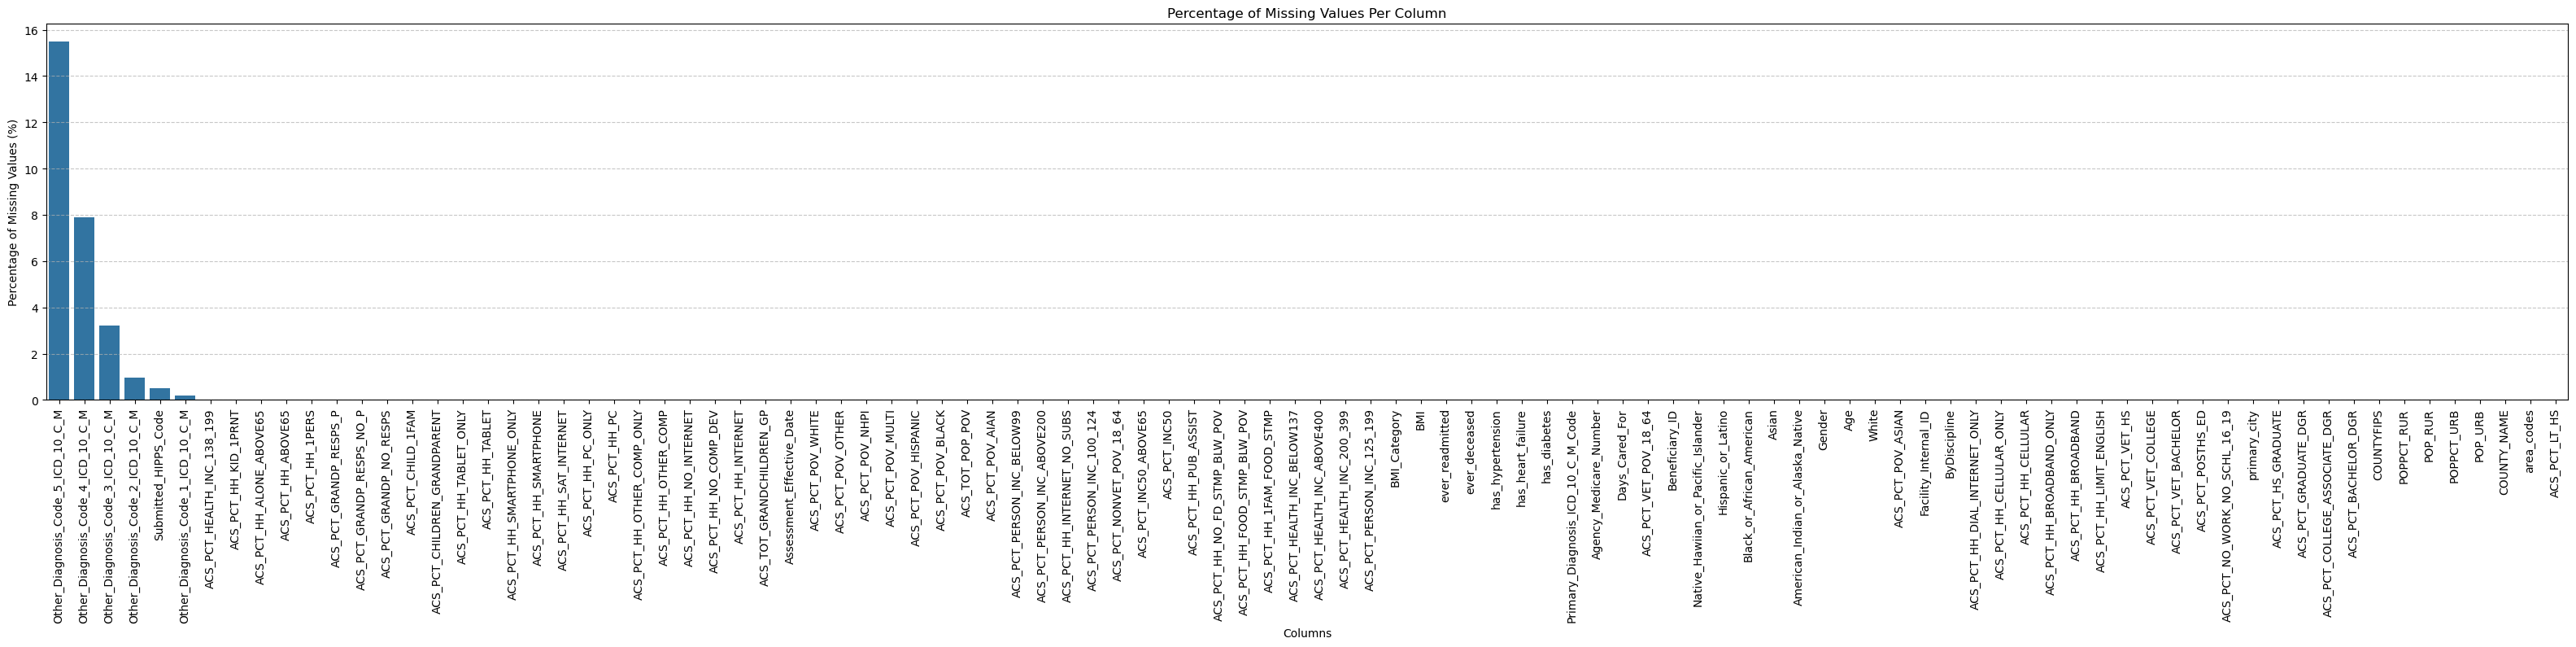

In [46]:
missing_percentage = (df_merged.isna().sum() / len(df_merged)) * 100

# Convert to DataFrame and sort by missing percentage
missing_percentage = missing_percentage.sort_values(ascending=False).to_frame('Missing Percentage')

# Plotting the missing percentage
plt.figure(figsize=(40, 6))
sns.barplot(x=missing_percentage.index, y=missing_percentage['Missing Percentage'])
plt.xticks(rotation=90, fontsize=10)
plt.ylabel('Percentage of Missing Values (%)')
plt.xlabel('Columns')
plt.title('Percentage of Missing Values Per Column')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [47]:
spark.stop()